<a href="https://colab.research.google.com/github/arxsyy/MachineLearning_2026/blob/main/JS05_TUGAS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TUGAS LAB 1**

**Nomor 1 – Membuat Model Klasifikasi KNN**

In [1]:
# Import library untuk pengolahan dan visualisasi data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset voice.csv
df = pd.read_csv('/content/voice.csv')

# Menampilkan 5 baris pertama
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [2]:
# Menampilkan ukuran dataset
print("Dimensi data:", df.shape)

# Menampilkan informasi setiap kolom
df.info()

# Mengecek jumlah missing value
print("\nMissing value:")
print(df.isnull().sum())

# Menghitung jumlah data pada setiap kelas
print("\nJumlah data per kelas:")
print(df['label'].value_counts())

# Menampilkan statistik deskriptif
df.describe()

Dimensi data: (3168, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000
mean,0.180907,0.057126,0.185621,0.140456,0.224765,0.084309,3.140168,36.568461,0.895127,0.408216,0.165282,0.180907,0.142807,0.036802,0.258842,0.829211,0.052647,5.047277,4.994630,0.173752
std,0.029918,0.016652,0.036360,0.048680,0.023639,0.042783,4.240529,134.928661,0.044980,0.177521,0.077203,0.029918,0.032304,0.019220,0.030077,0.525205,0.063299,3.521157,3.520039,0.119454
min,0.039363,0.018363,0.010975,0.000229,0.042946,0.014558,0.141735,2.068455,0.738651,0.036876,0.000000,0.039363,0.055565,0.009775,0.103093,0.007812,0.004883,0.007812,0.000000,0.000000
25%,0.163662,0.041954,0.169593,0.111087,0.208747,0.042560,1.649569,5.669547,0.861811,0.258041,0.118016,0.163662,0.116998,0.018223,0.253968,0.419828,0.007812,2.070312,2.044922,0.099766
50%,0.184838,0.059155,0.190032,0.140286,0.225684,0.094280,2.197101,8.318463,0.901767,0.396335,0.186599,0.184838,0.140519,0.046110,0.271186,0.765795,0.023438,4.992188,4.945312,0.139357
75%,0.199146,0.067020,0.210618,0.175939,0.243660,0.114175,2.931694,13.648905,0.928713,0.533676,0.221104,0.199146,0.169581,0.047904,0.277457,1.177166,0.070312,7.007812,6.992188,0.209183
max,0.251124,0.115273,0.261224,0.247347,0.273469,0.252225,34.725453,1309.612887,0.981997,0.842936,0.280000,0.251124,0.237636,0.204082,0.279114,2.957682,0.458984,21.867188,21.843750,0.932374


In [3]:
# Menentukan fitur dan target
X = df.drop('label', axis=1)
y = df['label']

# Memeriksa dimensi fitur dan target
print("Dimensi X:", X.shape)
print("Dimensi y:", y.shape)

Dimensi X: (3168, 20)
Dimensi y: (3168,)


In [4]:
# Import library untuk membagi dataset
from sklearn.model_selection import train_test_split

# Membagi dataset menjadi training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menampilkan dimensi hasil pembagian
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2534, 20)
X_test : (634, 20)
y_train: (2534,)
y_test : (634,)


In [5]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Membuat objek scaler
scaler = StandardScaler()

# Melakukan scaling pada data training dan testing
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Import algoritma KNN
from sklearn.neighbors import KNeighborsClassifier

# Membuat model KNN dengan k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Melatih model menggunakan data training
knn.fit(X_train_scaled, y_train)

# Melakukan prediksi pada data testing
y_pred = knn.predict(X_test_scaled)

In [7]:
# Import metrik evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# Menghitung akurasi, presisi dan recall
akurasi = accuracy_score(y_test, y_pred)
presisi = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

# Menampilkan hasil evaluasi
print("Akurasi :", akurasi)
print("Presisi :", presisi)
print("Recall  :", recall)

# Menampilkan laporan klasifikasi
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi : 0.9763406940063092
Presisi : 0.9765730784547988
Recall  : 0.9763406940063091

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



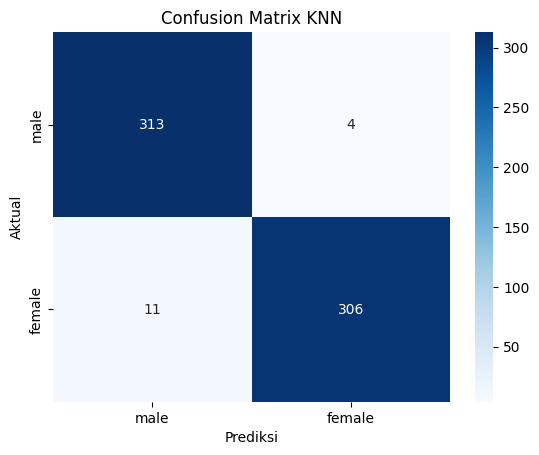

In [8]:
# Membuat confusion matrix
cm = confusion_matrix(
    y_test, y_pred,
    labels=['male', 'female']
)

# Menampilkan confusion matrix dengan heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['male', 'female'],
    yticklabels=['male', 'female']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix KNN')
plt.show()

**Nomor 2 – Percobaan Pemilihan Fitur Optimal**

In [9]:
# Import library untuk seleksi fitur dan validasi model
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Menentukan metode cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [10]:
# Menentukan variasi jumlah fitur
jumlah_fitur = [2, 4, 6, 8, 10, 12, 15, 20]

# Menyimpan hasil akurasi setiap percobaan
hasil_fitur = []

# Melakukan percobaan untuk setiap jumlah fitur
for n in jumlah_fitur:

    # Membuat pipeline scaling, seleksi fitur, dan KNN
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('seleksi', SelectKBest(f_classif, k=n)),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    # Menghitung akurasi dengan cross-validation
    skor = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    # Menyimpan rata-rata akurasi
    hasil_fitur.append(skor.mean())

# Menampilkan hasil percobaan
tabel_fitur = pd.DataFrame({
    'Jumlah Fitur': jumlah_fitur,
    'Akurasi': hasil_fitur
})

print(tabel_fitur)

   Jumlah Fitur   Akurasi
0             2  0.968034
1             4  0.972373
2             6  0.979872
3             8  0.979082
4            10  0.978686
5            12  0.974742
6            15  0.973161
7            20  0.969609


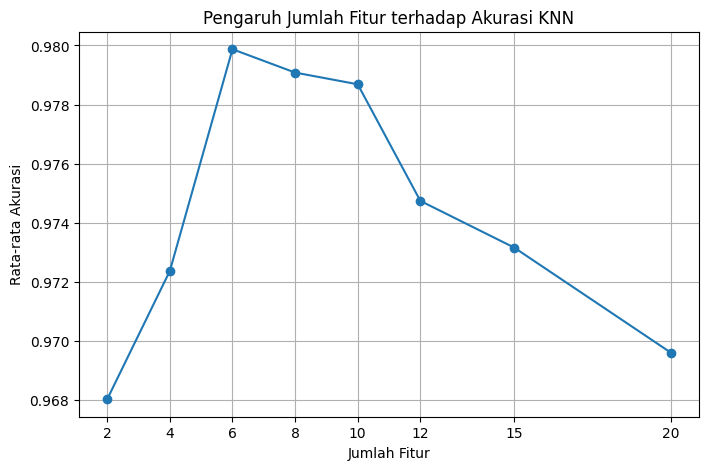

In [11]:
# Membuat grafik jumlah fitur terhadap akurasi
plt.figure(figsize=(8, 5))

plt.plot(
    jumlah_fitur,
    hasil_fitur,
    marker='o'
)

plt.xlabel('Jumlah Fitur')
plt.ylabel('Rata-rata Akurasi')
plt.title('Pengaruh Jumlah Fitur terhadap Akurasi KNN')
plt.xticks(jumlah_fitur)
plt.grid(True)

plt.show()

In [12]:
# Menentukan jumlah fitur dengan akurasi tertinggi
best_n = jumlah_fitur[np.argmax(hasil_fitur)]

# Membuat pipeline berdasarkan jumlah fitur terbaik
model_fitur = Pipeline([
    ('scaler', StandardScaler()),
    ('seleksi', SelectKBest(f_classif, k=best_n)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Melatih model menggunakan data training
model_fitur.fit(X_train, y_train)

# Mengambil nama fitur yang terpilih
fitur_terbaik = X_train.columns[
    model_fitur.named_steps['seleksi'].get_support()
].tolist()

# Menampilkan hasil
print("Jumlah fitur terbaik:", best_n)
print("Fitur yang digunakan:", fitur_terbaik)
print("Akurasi cross-validation tertinggi:", max(hasil_fitur))

Jumlah fitur terbaik: 6
Fitur yang digunakan: ['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']
Akurasi cross-validation tertinggi: 0.9798715220119902


**Nomor 3 – Menentukan Nilai k Terbaik**

In [13]:
# Menentukan variasi nilai k
nilai_k = list(range(1, 26, 2))

# Menyimpan hasil akurasi
akurasi_k = []

# Melakukan percobaan untuk setiap nilai k
for k in nilai_k:

    # Membuat pipeline menggunakan jumlah fitur terbaik
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('seleksi', SelectKBest(f_classif, k=best_n)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # Menghitung rata-rata akurasi cross-validation
    skor = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy'
    )

    # Menyimpan hasil akurasi
    akurasi_k.append(skor.mean())

# Menampilkan hasil setiap nilai k
tabel_k = pd.DataFrame({
    'Nilai k': nilai_k,
    'Akurasi': akurasi_k
})

print(tabel_k)

    Nilai k   Akurasi
0         1  0.972768
1         3  0.981449
2         5  0.979872
3         7  0.978687
4         9  0.975924
5        11  0.975531
6        13  0.973952
7        15  0.973557
8        17  0.970399
9        19  0.970005
10       21  0.969610
11       23  0.968821
12       25  0.967637


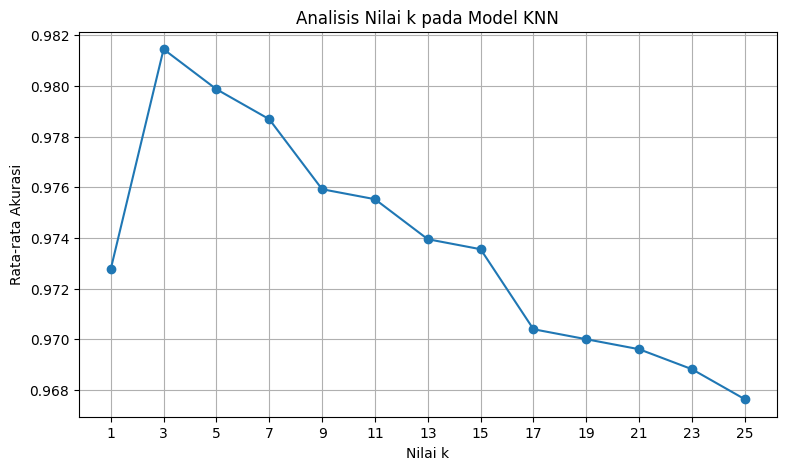

In [14]:
# Menampilkan grafik pengaruh nilai k terhadap akurasi
plt.figure(figsize=(9, 5))

plt.plot(
    nilai_k,
    akurasi_k,
    marker='o'
)

plt.xlabel('Nilai k')
plt.ylabel('Rata-rata Akurasi')
plt.title('Analisis Nilai k pada Model KNN')
plt.xticks(nilai_k)
plt.grid(True)

plt.show()

In [15]:
# Mengambil nilai k dengan akurasi tertinggi
best_k = nilai_k[np.argmax(akurasi_k)]

# Menampilkan hasil
print("Nilai k terbaik:", best_k)
print("Akurasi tertinggi:", max(akurasi_k))

Nilai k terbaik: 3
Akurasi tertinggi: 0.9814494312822072


In [16]:
# Membuat model final menggunakan parameter terbaik
model_final = Pipeline([
    ('scaler', StandardScaler()),
    ('seleksi', SelectKBest(f_classif, k=best_n)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

# Melatih model final menggunakan data training
model_final.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred_final = model_final.predict(X_test)

# Menampilkan hasil evaluasi
print("Jumlah fitur terbaik:", best_n)
print("Nilai k terbaik:", best_k)

print("\nAkurasi:", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Jumlah fitur terbaik: 6
Nilai k terbaik: 3

Akurasi: 0.9873817034700315

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.99      0.99       317
        male       0.99      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634



In [17]:
# Membandingkan akurasi model awal dan model final
perbandingan = pd.DataFrame({
    'Model': [
        'KNN Awal',
        'KNN Final'
    ],
    'Akurasi': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_final)
    ]
})

print(perbandingan)

       Model   Akurasi
0   KNN Awal  0.976341
1  KNN Final  0.987382


Analisis nomor 3: Percobaan dilakukan dengan menggunakan fitur terbaik dari nomor 2 dan menguji nilai k dari 1 sampai 25. Nilai k dipilih berdasarkan rata-rata akurasi cross-validation tertinggi. Penggunaan nilai k yang terlalu kecil dapat membuat model sensitif terhadap noise, sedangkan nilai k yang terlalu besar dapat mengurangi kemampuan model membedakan kelas. Hasil model final kemudian dievaluasi pada data testing untuk mengetahui performanya pada data yang belum digunakan dalam pelatihan.